# Lab 2: Locating the Fermat point
**Python supplement · Worked solutions · English**

Explore a distance-sum landscape without derivatives; visualize the transition at 120 degrees.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')




## Exercise 2.1: A triangular grid and the 120-degree configuration

For $A=(0,0)$, $B=(2,0)$, $C=(0,2)$, minimize
$F(X)=|X-A|+|X-B|+|X-C|$ over the filled triangle.

**Code tasks (30–40 minutes).**
1. Build the barycentric grid $X=A+(i/m)(B-A)+(j/m)(C-A)$,
   with $i,j\geq0$ and $i+j\leq m$. Evaluate the distance sum.
2. Return all grid points, their values and a minimizing point. Draw a
   colored scatter plot, and join the best point to the vertices.
3. Increase $m$ through 20, 40, 80. Compare with the exact point
   $T=(1-1/\sqrt3,1-1/\sqrt3)$ and measure the three angles there.

**Return contract:** `(points, values, best)` from `fermat_grid(vertices, m)`.
Broadcasting hint: `points[:, None, :] - vertices[None, :, :]` has shape
`(number_of_points, 3, 2)`. Sum Euclidean distances over the three vertices.


In [2]:
def fermat_grid(vertices, m):
    weights = np.array([(i/m, j/m) for i in range(m+1) for j in range(m+1-i)])
    A, B, C = vertices
    points = A + weights[:, :1]*(B-A) + weights[:, 1:]*(C-A)
    values = np.linalg.norm(points[:, None, :]-vertices[None, :, :], axis=2).sum(axis=1)
    return points, values, points[np.argmin(values)]


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

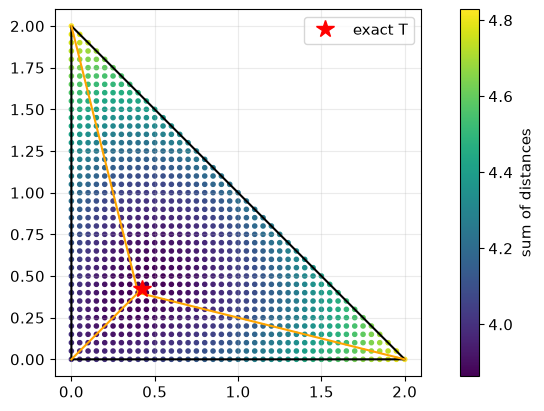

m=20: T_grid=[0.4 0.4], coordinate error=0.032032, F=3.8641699
m=40: T_grid=[0.4 0.4], coordinate error=0.032032, F=3.8641699
m=80: T_grid=[0.425 0.425], coordinate error=0.0033238, F=3.8637084
Angles at the exact T: [120. 120. 120.]


In [3]:
vertices = np.array([[0., 0.], [2., 0.], [0., 2.]])
result = fermat_grid(vertices, 40)
if result is None:
    print('Complete fermat_grid, then rerun this cell.')
else:
    points, values, best = result
    exact = np.full(2, 1-1/np.sqrt(3))
    fig, ax = plt.subplots()
    sc = ax.scatter(points[:, 0], points[:, 1], c=values, s=9, cmap='viridis')
    outline(ax, vertices, color='black')
    for v in vertices:
        ax.plot([best[0], v[0]], [best[1], v[1]], color='orange')
    ax.plot(*exact, 'r*', ms=13, label='exact T'); ax.legend()
    fig.colorbar(sc, ax=ax, label='sum of distances'); plt.show()
    errors = []
    for m in (20, 40, 80):
        _, vals, point = fermat_grid(vertices, m)
        errors.append(np.linalg.norm(point-exact))
        print(f'm={m}: T_grid={point}, coordinate error={errors[-1]:.5g}, F={vals.min():.7f}')
    assert errors[-1] < 0.04
    rays = vertices-exact
    rays /= np.linalg.norm(rays, axis=1)[:, None]
    angles = np.degrees(np.arccos(np.clip(rays @ rays.T, -1, 1)))
    np.testing.assert_allclose(angles[np.triu_indices(3, 1)], 120., atol=1e-10)
    print('Angles at the exact T:', angles[np.triu_indices(3, 1)])


**Explain your observations.** Does a grid minimizer establish optimality over the whole triangle? Explain why angle measurements at a grid point need not be exactly 120 degrees.

**Solution guidance:** The exact Fermat point has three 120-degree angles. Grid points typically do not. Since the grid is a subset of the triangle, its best value is an upper bound on the continuous minimum. The geometric proof in the course supplies the global conclusion.

## Exercise 2.2: When does the minimizer reach a vertex?

Use $A=(0,0)$, $B=(1,0)$, $C=(\cos\alpha,\sin\alpha)$, for
$60^\circ\leq\alpha\leq150^\circ$. Symmetry puts the optimizer on
the angle bisector. Write $X=t(\cos(\alpha/2),\sin(\alpha/2))$;
the part inside the triangle has $0\leq t\leq\cos(\alpha/2)$.

**Code tasks (30–40 minutes).**
1. Complete `bisector_search(alpha_degrees, count)` by sampling that segment,
   including $t=0$. Evaluate the **unsmoothed** distance sum.
2. Plot the best $t$ against $\alpha$, then draw configurations at
   $90^\circ$, $120^\circ$ and $140^\circ$.
3. Refine the segment grid near the transition. Compare with the supplied
   geometric formula $t_*=\max(0,\cos(\alpha/2)-\sin(\alpha/2)/\sqrt3)$.

**Return contract:** `(vertices, best_point, best_t)`.
The symmetry reduction uses convexity of the distance sum: averaging a
point with its reflected point cannot increase the objective. This fact is
supplied here and studied systematically in Session 3. No gradient is needed.


In [4]:
def bisector_search(alpha_degrees, count=2001):
    alpha = np.radians(alpha_degrees)
    vertices = np.array([[0., 0.], [1., 0.], [np.cos(alpha), np.sin(alpha)]])
    direction = np.array([np.cos(alpha/2), np.sin(alpha/2)])
    t = np.linspace(0, np.cos(alpha/2), count)
    points = t[:, None]*direction
    values = np.linalg.norm(points[:, None, :]-vertices[None, :, :], axis=2).sum(axis=1)
    k = np.argmin(values)
    return vertices, points[k], t[k]


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

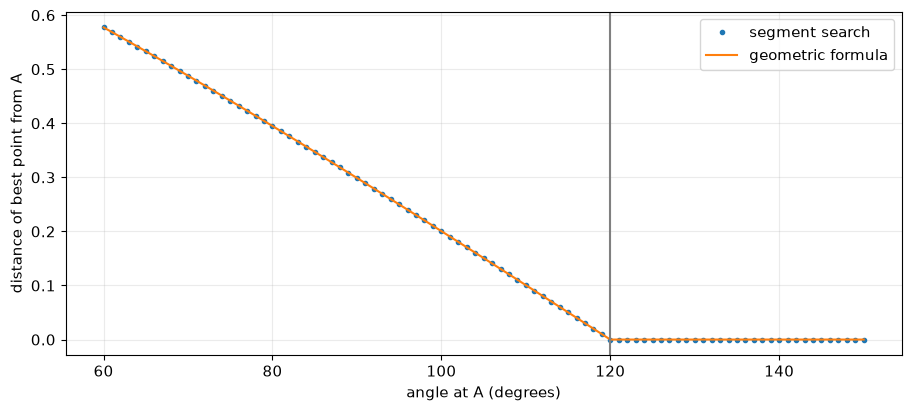

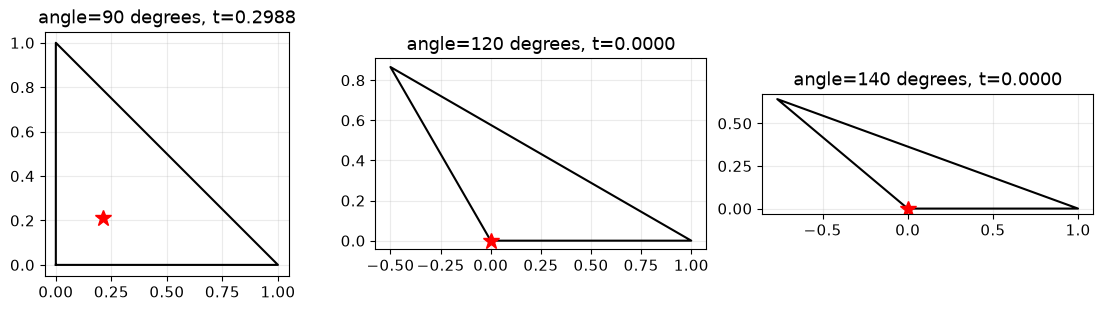

In [5]:
result = bisector_search(90.)
if result is None:
    print('Complete bisector_search, then rerun this cell.')
else:
    alpha = np.linspace(60, 150, 91)
    numerical = np.array([bisector_search(a)[2] for a in alpha])
    half = np.radians(alpha/2)
    exact = np.maximum(0, np.cos(half)-np.sin(half)/np.sqrt(3))
    np.testing.assert_allclose(numerical, exact, atol=5e-4)
    plt.plot(alpha, numerical, '.', label='segment search')
    plt.plot(alpha, exact, label='geometric formula'); plt.axvline(120, color='gray')
    plt.xlabel('angle at A (degrees)'); plt.ylabel('distance of best point from A')
    plt.legend(); plt.show()
    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    for ax, angle in zip(axes, [90., 120., 140.]):
        v, point, t = bisector_search(angle)
        outline(ax, v, color='black'); ax.plot(*point, 'r*', ms=12)
        ax.set_title(f'angle={angle:g} degrees, t={t:.4f}')
    plt.show()
    np.testing.assert_allclose(bisector_search(140.)[1], [0, 0], atol=1e-12)


**Explain your observations.** Why must the search include the endpoint? Why would replacing distances by smoothed distances change the vertex behavior?

**Solution guidance:** The exact bisector coordinate decreases to zero at 120 degrees and remains zero above it. Excluding t=0 would exclude the optimizer in that regime. A smoothed distance removes the original nonsmooth vertex behavior and solves a different problem.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.